# Hotel Booking Cancellation Forecasting — Dynamic Inventory Protection Pipeline

## Business Problem

Hotel rooms are perishable inventory: a room left empty on a given night is revenue lost forever, it cannot be "restocked" and sold later. Cancellations are the single biggest source of this lost revenue, but they are not random. Their likelihood varies systematically with factors such as lead time, deposit type, market segment, and a guest's booking history.

A Revenue Manager's practical challenge is deciding, for each night on the books, **how much to rely on the reservations currently on the books versus how much spare capacity to release for new sales** in anticipation of cancellations that haven't happened yet. Guessing too conservatively wastes inventory; guessing too aggressively risks overselling. Getting this right requires an up-to-date, booking-level estimate of cancellation risk, refreshed daily as new information (lead time shortens, deposits are paid, etc.) comes in.

## Project Goal

This notebook builds an end-to-end pipeline that turns raw historical booking data into a **daily-refreshed cancellation risk score per active reservation**, ready to be consumed by a BI dashboard. Concretely, it:

1. Cleans and engineers features from the raw booking data.
2. Trains and validates a machine learning model to estimate cancellation probability per booking.
3. Calibrates three risk-appetite thresholds (**Aggressive**, **Balanced**, **Cautious**) so the same model output can support different overbooking strategies.
4. Runs a **"time-machine" simulation**: for every calendar day in the dataset's history, it reconstructs which reservations were "active" as of that day and what the model would have predicted for them at that moment — replicating how a Revenue Manager would review at-risk bookings each morning.
5. Exports the results to a flat file, ready to be plugged into a Tableau dashboard.

The two hotels in the dataset (City Hotel and Resort Hotel) are modeled separately throughout, since they show materially different booking patterns and cancellation dynamics.

## Key Limitation & Scope Decision

The dataset used here is a **static historical extract** covering only a portion of each hotel's true reservation volume for the period (July 2015 – August 2017), rather than a complete, continuously-updated view of every reservation on file. This matters because it deprives the model of two signals a real Revenue Management System normally relies on heavily:

- **Booking pace / pick-up**: how quickly rooms for a given arrival date are being reserved relative to the same point in previous cycles — a strong leading indicator of demand and, indirectly, of cancellation risk.
- **Full seasonality curve**: the complete year-round demand pattern, since the dataset only contains a partial sample of what was actually on the books.

We partially compensated for the missing seasonality signal by engineering explicit **Portuguese public holiday and long-weekend ("bridge") features** (Step 3 below), which recover some of the demand-driver signal that would otherwise come from pick-up pace. This helped meaningfully for the Resort Hotel, whose demand is more strongly holiday- and leisure-driven.

For the City Hotel, however — whose demand depends more on business travel patterns and short-term pick-up dynamics that this dataset does not expose — the added features were not enough to bring model accuracy to an acceptable standard.

**As a result, the final production export to Tableau (Stage 5) is scoped to the Resort Hotel only.** The City Hotel modeling work is kept in this notebook for transparency and to document the diagnostic process, but its output is not part of the delivered dashboard.

## Source Data

**File:** `hotel_bookings.csv` — the *Hotel Booking Demand* dataset (Nekouei, Kaggle), containing 119,390 individual bookings across 32 columns for a City Hotel and a Resort Hotel in Portugal, spanning arrivals from July 2015 to August 2017.

## Tools Used

- **Python** (pandas, NumPy) for data cleaning and feature engineering
- **Matplotlib / Seaborn** for exploratory data analysis and diagnostic plots
- **scikit-learn** (RandomForestClassifier, HistGradientBoostingClassifier) for model training and evaluation
- **`holidays`** library for Portuguese public holiday and "bridge day" feature engineering
- **Tableau Public** as the downstream BI layer consuming this pipeline's output
- **GitHub / Kaggle** for portfolio publication

## Pipeline Structure

| Stage | What it covers |
| :--- | :--- |
| **1. Data Inspection** | Exploring data quality issues, anomalies, and distributions in the raw dataset |
| **2. Data Cleaning** | Date reconstruction, occupancy rule enforcement, and cascading imputation of missing/invalid ADR values |
| **3. Feature Engineering** | ADR-based anomaly reclassification, Portuguese holiday & bridge-stay features, encoding of the final feature matrix |
| **4. Model Validation** | Benchmarking temporal train/test split strategies to prevent data leakage, and selecting the final configuration |
| **5. Production Simulation & Export** | Training the production model, running the daily time-machine simulation, and exporting the dataset for Tableau — **Resort Hotel only**, per the scope decision above |

Each stage below includes its own markdown commentary explaining the results of the previous step and the reasoning behind the choices made (thresholds, imputation logic, feature selection, etc.).

**Note on numbering:** the table above groups the notebook into 5 macro **Stages**. Each stage is broken down further into individually numbered **Steps** (Step 0 through Step 8), which is the numbering used on the section headers throughout the notebook. The mapping is:

| Stage | Steps |
|---|---|
| 1. Data Inspection | Step 0, Further Data Inspection |
| 2. Data Cleaning | Step 1, Step 2 |
| 3. Feature Engineering | Step 3, Step 4 |
| 4. Model Validation | Step 5, Selection Rationale, Step 6, Step 7 |
| 5. Production Simulation & Export | Step 8 |

### Step 0: Environment Setup & Initial Data Load

Before any cleaning or modeling can begin, this first block of code takes care of three preliminary tasks:

1. **Environment Setup:** Imports the core libraries used throughout the notebook (`pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, `scikit-learn` for modeling) and configures a consistent plot theme and logging format, so every step below reports its progress and results in a uniform, readable way.

2. **Data Loading:** Reads the raw `hotel_bookings.csv` file into a working DataFrame (`df`), with a basic error check in case the source file is missing or misplaced.

3. **Structural Inspection:** Runs a first, high-level scan of the data before any cleaning decision is made:
   - Previews the first rows and the full column/data-type structure (`df.info()`).
   - Reports the **min/max range of every numerical column**, to catch obviously invalid values (e.g. negative or unrealistic entries) at a glance.
   - Reports the **min/max frequency of every categorical column**, to flag categories that are either near-universal or vanishingly rare.
   - Plots the number of bookings by hotel type, to confirm how the two hotels are represented in the raw dataset before any splitting or modeling happens.

This step is intentionally observational: nothing is modified or dropped yet. Its purpose is to build an evidence-based picture of the dataset's quality issues, which then directly informs the cleaning rules applied in the next steps.

2026-07-29 11:10:06,736 - INFO - Loading dataset from ../raw data/hotel_bookings.csv...
2026-07-29 11:10:06,947 - INFO - SUCCESS: Dataset loaded with 119,390 rows and 32 columns.


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,01-07-15
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15


2026-07-29 11:10:06,987 - INFO - Column 'is_canceled': min=0, max=1
2026-07-29 11:10:06,987 - INFO - Column 'lead_time': min=0, max=737
2026-07-29 11:10:06,988 - INFO - Column 'arrival_date_year': min=2015, max=2017
2026-07-29 11:10:06,989 - INFO - Column 'arrival_date_week_number': min=1, max=53
2026-07-29 11:10:06,990 - INFO - Column 'arrival_date_day_of_month': min=1, max=31
2026-07-29 11:10:06,991 - INFO - Column 'stays_in_weekend_nights': min=0, max=19
2026-07-29 11:10:06,992 - INFO - Column 'stays_in_week_nights': min=0, max=50
2026-07-29 11:10:06,992 - INFO - Column 'adults': min=0, max=55
2026-07-29 11:10:06,993 - INFO - Column 'children': min=0.0, max=10.0
2026-07-29 11:10:06,994 - INFO - Column 'babies': min=0, max=10
2026-07-29 11:10:06,995 - INFO - Column 'is_repeated_guest': min=0, max=1
2026-07-29 11:10:06,996 - INFO - Column 'previous_cancellations': min=0, max=26
2026-07-29 11:10:06,997 - INFO - Column 'previous_bookings_not_canceled': min=0, max=72
2026-07-29 11:10:06,

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

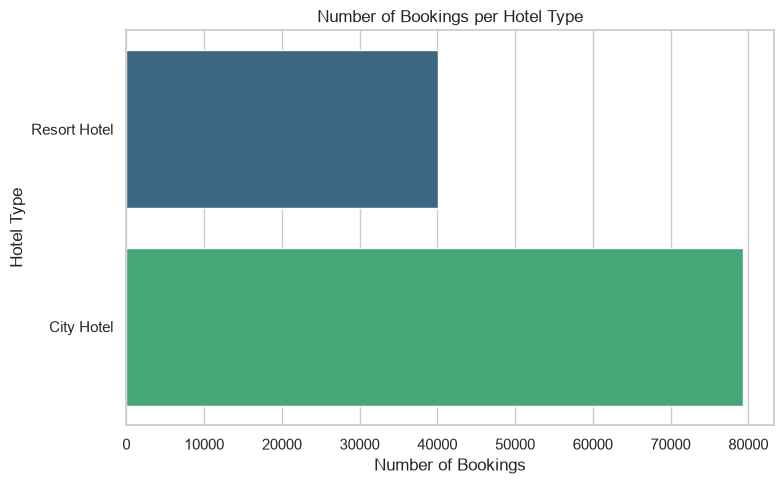

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import logging

# Configure logging and theme
sns.set_theme(style="whitegrid")
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# File path targeting the external 'raw data' folder
INPUT_FILE = '../raw data/hotel_bookings.csv'

try:
    logging.info(f"Loading dataset from {INPUT_FILE}...")
    df = pd.read_csv(INPUT_FILE)
    logging.info(f"SUCCESS: Dataset loaded with {len(df):,} rows and {len(df.columns)} columns.")

    # Display the first few rows (with fallback for standard scripts)
    try:
        display(df.head(3))
    except NameError:
        print(df.head(3))

    df.info()

    # Show the min and max of all numerical columns
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        logging.info(f"Column '{col}': min={min_val}, max={max_val}")

    # Show the min and max count of all unique values in the categorical columns
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        value_counts = df[col].value_counts()
        min_count = value_counts.min()
        max_count = value_counts.max()
        logging.info(f"Column '{col}': min count={min_count}, max count={max_count}")

    # Plot a horizontal bar chart of the number of bookings per hotel type
    plt.figure(figsize=(8, 5))
    sns.countplot(y='hotel', data=df, hue='hotel', palette='viridis', legend=False)
    plt.title('Number of Bookings per Hotel Type')
    plt.xlabel('Number of Bookings')
    plt.ylabel('Hotel Type')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    logging.error(f"Could not find {INPUT_FILE}. Please check if the 'raw data' folder and file name are correct.")

### Further Data Inspection: Pricing Anomalies & Category Frequencies

Building on the first structural pass, this step digs one level deeper into two specific risk areas before any cleaning rule is written:

1. **ADR Distribution by Market Segment & Hotel:** A boxplot of Average Daily Rate (ADR) across market segments and hotel types (capped at $1,000 for readability against extreme outliers) is used to visually screen for pricing anomalies — segments or hotels showing implausibly low or inconsistent rates. This check is what first surfaces the cluster of non-complementary bookings priced near $0, which is addressed directly in the next step (**Nominal ADR Reclassification**).

2. **Low-Frequency Categories:** Distribution channels and market segments occurring in less than 0.5% of total bookings are listed explicitly. Rare categories like these can behave unpredictably once one-hot encoded (e.g. contributing noisy, near-empty columns to the feature matrix), so flagging them here ensures none are hiding a data quality issue that would need special handling before modeling.

Together, these two checks confirm that the dataset's main outstanding structural problem is the ADR pricing anomaly, while category frequencies remain distributed enough not to require dedicated grouping at this stage (unlike `country`, which is grouped later due to a much larger number of sparse values).

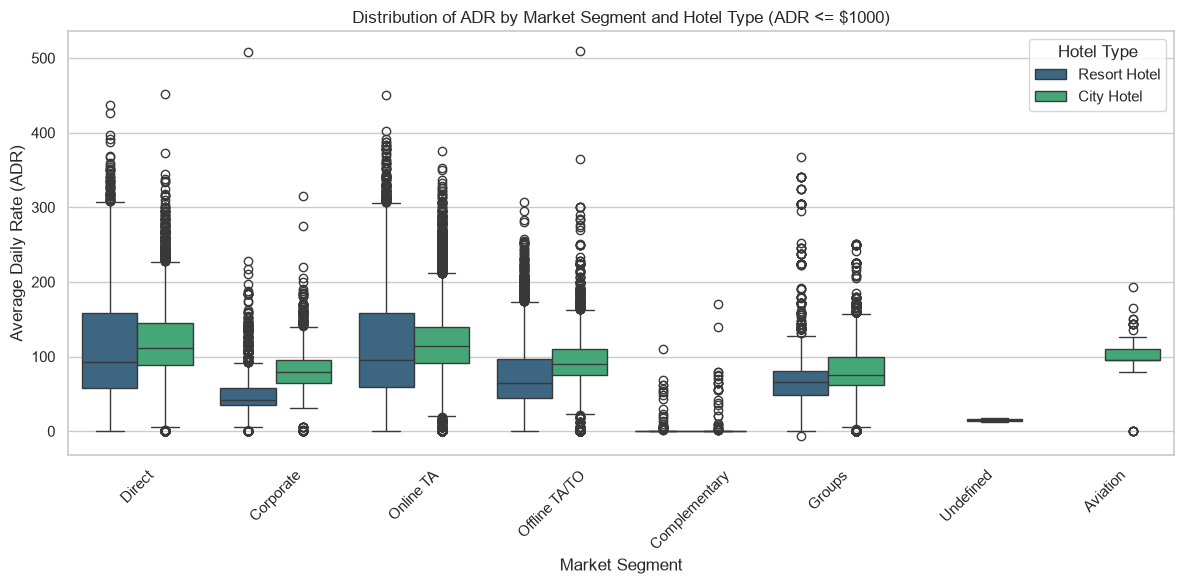

--- Low-Frequency Distribution Channels (< 0.5%) ---
Distribution Channel: GDS | Count: 193 (0.16%)
Distribution Channel: Undefined | Count: 5 (0.00%)

--- Low-Frequency Market Segments (< 0.5%) ---
Market Segment: Aviation | Count: 237 (0.20%)
Market Segment: Undefined | Count: 2 (0.00%)


In [2]:
# Further data inspection

# 1 - ADR distribution by Market Segment and Hotel Type
# Visualizing potential pricing anomalies across segments
plt.figure(figsize=(12, 6))

# Capping visualization at $1000 to keep the plot readable against severe raw outliers
sns.boxplot(
    y='adr', 
    x='market_segment', 
    data=df[df['adr'] <= 1000], 
    hue='hotel', 
    palette='viridis'
)
plt.title('Distribution of ADR by Market Segment and Hotel Type (ADR <= $1000)')
plt.xlabel('Market Segment')
plt.ylabel('Average Daily Rate (ADR)')
plt.xticks(rotation=45)
plt.legend(title='Hotel Type')
plt.tight_layout()
plt.show()

# 2 - Low-frequency distribution channels and market segments
# Filtering out segments/channels occurring in less than 0.5% of total bookings
total_rows = len(df)
distribution_channel_counts = df['distribution_channel'].value_counts(dropna=False)
market_segment_counts = df['market_segment'].value_counts(dropna=False)

print("--- Low-Frequency Distribution Channels (< 0.5%) ---")
for channel, count in distribution_channel_counts.items():
    pct = (count / total_rows) * 100
    if count / total_rows < 0.005:
        print(f"Distribution Channel: {channel} | Count: {count:,} ({pct:.2f}%)")

print("\n--- Low-Frequency Market Segments (< 0.5%) ---")
for segment, count in market_segment_counts.items():
    pct = (count / total_rows) * 100
    if count / total_rows < 0.005:
        print(f"Market Segment: {segment} | Count: {count:,} ({pct:.2f}%)")

### Step 1: Data Cleaning & Smart ADR Imputation

Inspecting the raw dataset, we identified a set of data-entry issues and structural inconsistencies that need to be resolved before any feature engineering or modeling can take place:

1. **Date & Chronology Engineering:** Parses raw calendar components (`arrival_date_year`, `arrival_date_month`, `arrival_date_day_of_month`) into standard chronological `arrival_date` objects, and back-calculates `booking_date` using the `lead_time` feature (dropping rows with unparseable dates, if any).

2. **Occupancy Enforcement:** Enforces valid booking occupancy by ensuring every record has at least 1 adult (correcting records where adults equaled zero) and capping maximum adult occupancy at 3.

3. **Children & Babies Outlier Capping:** Limits abnormal or erroneous inputs for children and babies to a maximum of 2.

4. **Cascade Waterfall Imputation for Prices (ADR):** For non-complementary bookings showing a price of zero or negative, the function replaces the missing value using a multi-level fallback system — from the most specific match (hotel + market segment + room type + arrival date) down to the broadest (hotel + market segment medians) — so each imputed price stays as close as possible to comparable real bookings.

5. **Price Capping & Filtering:** Caps extreme daily rates at $500.00 to prevent pricing anomalies from skewing the model, while validating the resulting low-rate distribution.

6. **Country Grouping:** Merges rare countries with fewer than 20 occurrences into a single `'Other'` category to prevent the model from overfitting on sparse geographical data.

7. **Non-Refundable Cancellation Override:** For Non-Refundable bookings, the cancellation flag (`is_canceled`) is reset to 0. Since payment for these bookings is retained by the hotel regardless of guest behavior, a formal "cancellation" on a Non-Refundable booking carries no revenue risk — so it is treated as a non-event for the purposes of this project, whose goal is to forecast bookings that put revenue genuinely at risk.

**Result:**

- **No rows lost:** all 119,390 bookings from the raw file are retained after cleaning — no dates failed to parse, and the ADR filtering/imputation logic resolved every invalid price without needing to drop any records.
- **1,280 bookings** (non-complementary, zero or negative ADR) were repaired through the cascade waterfall imputation; a further 680 zero-ADR bookings under the `Complementary` segment were left untouched, since a $0 rate is expected and legitimate for that segment.
- **403 bookings** had `adults` corrected from 0 to 1 under the minimum-occupancy rule.
- **Country cardinality reduced from 177 to 76 categories** (488 originally missing values are left as-is at this stage, and are only imputed later during feature preparation).
- **14,494 of 14,587 Non-Refundable bookings (≈99.4%)** had originally been flagged as canceled. Overriding these — about **12% of the full dataset** — is the single largest adjustment made to the target variable in this notebook, and is carried through consistently into the final production model later on.

| Market Segment | Bookings with ADR < $10 (post-cleaning) | % of segment |
|---|---|---|
| Complementary | 708 | 95.29% |
| Groups | 86 | 0.43% |
| Direct | 51 | 0.40% |
| Online TA | 47 | 0.08% |
| Offline TA/TO | 37 | 0.15% |
| Corporate | 14 | 0.26% |

The near-total concentration of low-ADR bookings in the `Complementary` segment confirms that $0-range prices are largely expected there. The remaining ~235 low-ADR bookings scattered across paid segments are the anomaly investigated next, in **Step 2: Nominal ADR Reclassification**.

2026-07-29 11:10:07,552 - INFO - Starting comprehensive data cleaning and date engineering pipeline...
2026-07-29 11:10:07,658 - INFO - Imputing 1280 non-complementary bookings with zero ADR via waterfall logic...
2026-07-29 11:10:07,753 - INFO - Number of bookings with ADR below $10 per market segment after cleaning:
market_segment
Complementary    708
Corporate         14
Direct            51
Groups            86
Offline TA/TO     37
Online TA         47
dtype: int64
2026-07-29 11:10:07,753 - INFO - Percentage of bookings with ADR below $10 per market segment after cleaning:
market_segment
Aviation           NaN
Complementary    95.29
Corporate         0.26
Direct            0.40
Groups            0.43
Offline TA/TO     0.15
Online TA         0.08
Undefined          NaN
dtype: float64
2026-07-29 11:10:07,932 - INFO - 6. Number of bookings per country after grouping low-frequency countries into 'Other':
country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
       ..

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,0,Transient,105.0,0,0,Check-Out,01-07-15,2015-07-01,2014-07-24
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,NaN,0,Transient,105.0,0,0,Check-Out,01-07-15,2015-07-01,2013-06-24
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,NaN,0,Transient,75.0,0,0,Check-Out,02-07-15,2015-07-01,2015-06-24


2026-07-29 11:10:07,942 - INFO - Column 'is_canceled': min=0, max=1
2026-07-29 11:10:07,942 - INFO - Column 'lead_time': min=0, max=737
2026-07-29 11:10:07,943 - INFO - Column 'arrival_date_year': min=2015, max=2017
2026-07-29 11:10:07,943 - INFO - Column 'arrival_date_week_number': min=1, max=53
2026-07-29 11:10:07,944 - INFO - Column 'arrival_date_day_of_month': min=1, max=31
2026-07-29 11:10:07,944 - INFO - Column 'stays_in_weekend_nights': min=0, max=19
2026-07-29 11:10:07,944 - INFO - Column 'stays_in_week_nights': min=0, max=50
2026-07-29 11:10:07,945 - INFO - Column 'adults': min=1, max=3
2026-07-29 11:10:07,945 - INFO - Column 'children': min=0.0, max=2.0
2026-07-29 11:10:07,946 - INFO - Column 'babies': min=0, max=2
2026-07-29 11:10:07,946 - INFO - Column 'is_repeated_guest': min=0, max=1
2026-07-29 11:10:07,946 - INFO - Column 'previous_cancellations': min=0, max=26
2026-07-29 11:10:07,947 - INFO - Column 'previous_bookings_not_canceled': min=0, max=72
2026-07-29 11:10:07,947

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  str           
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  str           
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119390 non-null  float64       
 11

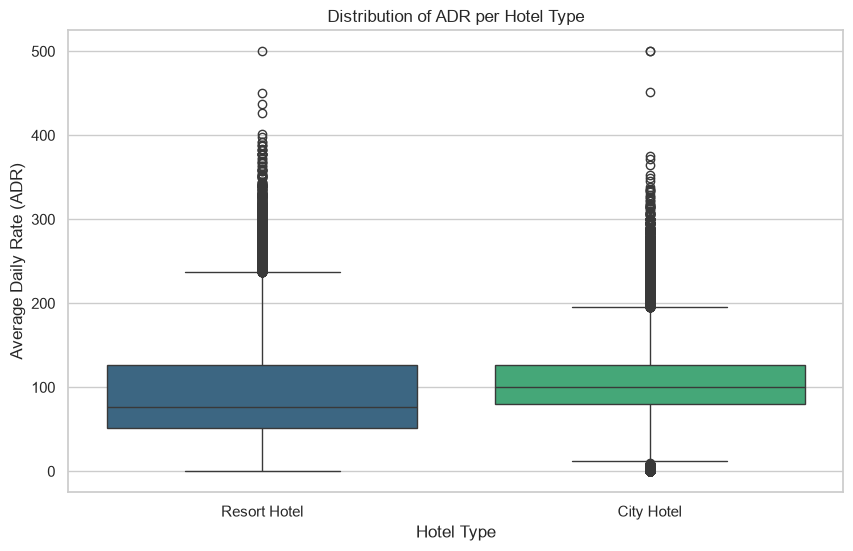

In [3]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """Engineers core dates, applies baseline business rules, cleans anomalies, and imputes missing values via waterfall logic."""
    logging.info("Starting comprehensive data cleaning and date engineering pipeline...")
    df = df.copy()

    # 1. Engineer arrival_date and booking_date from raw split components
    month_map = {
        'January': '01', 'February': '02', 'March': '03', 'April': '04',
        'May': '05', 'June': '06', 'July': '07', 'August': '08',
        'September': '09', 'October': '10', 'November': '11', 'December': '12'
    }

    months = df['arrival_date_month'].map(month_map)
    days = df['arrival_date_day_of_month'].astype(str).str.zfill(2)
    years = df['arrival_date_year'].astype(str)

    df['arrival_date'] = pd.to_datetime(years + '-' + months + '-' + days, errors='coerce')

    if 'lead_time' in df.columns:
        df['booking_date'] = df['arrival_date'] - pd.to_timedelta(df['lead_time'], unit='D')

    df = df.dropna(subset=['arrival_date'])

    # 2. Enforce minimum occupancy (at least 1 adult per booking), and max occupancy (maximum 3 adults per booking)
    df.loc[df['adults'] == 0, 'adults'] = 1
    df['adults'] = df['adults'].clip(upper=3)

    # 3. Cap extreme input errors for children and babies (max 2); missing children values are treated as 0
    df['children'] = df['children'].fillna(0).clip(upper=2)
    df['babies'] = df['babies'].clip(upper=2)

    # 4. CASCADE WATERFALL IMPUTATION FOR ZERO ADR VALUES
    mask_zero_not_comp = (df['adr'] <= 0) & (df['market_segment'] != 'Complementary')

    if mask_zero_not_comp.sum() > 0:
        logging.info(f"Imputing {mask_zero_not_comp.sum()} non-complementary bookings with zero ADR via waterfall logic...")

        # Calculate medians using valid historical bookings only (ADR > 0)
        df_valid = df[df['adr'] > 0]

        # Level 1: Hotel + Market Segment + Room Type + Arrival Date
        med1 = df_valid.groupby(['hotel', 'market_segment', 'reserved_room_type', 'arrival_date'])['adr'].median().reset_index(name='adr_l1')
        # Level 2: Hotel + Room Type + Arrival Date (ignoring market segment)
        med2 = df_valid.groupby(['hotel', 'reserved_room_type', 'arrival_date'])['adr'].median().reset_index(name='adr_l2')
        # Level 3: Hotel + Market Segment + Room Type (ignoring arrival date)
        med3 = df_valid.groupby(['hotel', 'market_segment', 'reserved_room_type'])['adr'].median().reset_index(name='adr_l3')
        # Level 4 (Safety Net): Hotel + Market Segment (ignoring room type and date)
        med4 = df_valid.groupby(['hotel', 'market_segment'])['adr'].median().reset_index(name='adr_l4')

        # Temporarily merge median levels back to the main dataframe
        df = df.merge(med1, on=['hotel', 'market_segment', 'reserved_room_type', 'arrival_date'], how='left')
        df = df.merge(med2, on=['hotel', 'reserved_room_type', 'arrival_date'], how='left')
        df = df.merge(med3, on=['hotel', 'market_segment', 'reserved_room_type'], how='left')
        df = df.merge(med4, on=['hotel', 'market_segment'], how='left')

        # Fill missing values in cascade order (L1 -> L2 -> L3 -> L4)
        df.loc[mask_zero_not_comp, 'adr'] = df.loc[mask_zero_not_comp, 'adr_l1'] \
            .fillna(df.loc[mask_zero_not_comp, 'adr_l2']) \
            .fillna(df.loc[mask_zero_not_comp, 'adr_l3']) \
            .fillna(df.loc[mask_zero_not_comp, 'adr_l4'])

        # Drop temporary calculation columns
        df = df.drop(columns=['adr_l1', 'adr_l2', 'adr_l3', 'adr_l4'])

    # 5. Final filter and outlier capping at $500.00
    valid_adr_mask = (df['adr'] > 0) | (df['market_segment'] == 'Complementary')
    df = df[valid_adr_mask].copy()
    df.loc[df['adr'] > 500.0, 'adr'] = 500.0

    # Inspect the number of adr values below 10 per market segment after cleaning
    adr_below_10 = df[df['adr'] < 10].groupby('market_segment').size()
    total_bookings = df.groupby('market_segment').size()
    adr_below_10_pct = (adr_below_10 / total_bookings * 100).round(2)
    logging.info(f"Number of bookings with ADR below $10 per market segment after cleaning:\n{adr_below_10}")
    logging.info(f"Percentage of bookings with ADR below $10 per market segment after cleaning:\n{adr_below_10_pct}")

    # 6. Group low-frequency countries (<20 occurrences) into 'Other'
    if 'country' in df.columns:
        country_counts = df['country'].value_counts(dropna=False)
        rare_countries = country_counts[country_counts < 20].index
        df['country'] = df['country'].replace(rare_countries, 'Other')

    if 'country' in df.columns:
        country_counts_after = df['country'].value_counts()
        logging.info(f"6. Number of bookings per country after grouping low-frequency countries into 'Other':\n{country_counts_after}")

    # 7. RULE 1: Override cancellations for Non-Refundable bookings (0 financial risk)
    df.loc[df['deposit_type'] == 'Non Refund', 'is_canceled'] = 0

    logging.info("Data cleaning and date engineering completed successfully.")
    
    try:
        display(df.head(3))
    except NameError:
        print(df.head(3))
        
    df.info()

    # Display min and max of all numerical columns after cleaning
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        min_val = df[col].min()
        max_val = df[col].max()
        logging.info(f"Column '{col}': min={min_val}, max={max_val}")

    return df

# --- EXECUTE FUNCTION & ASSIGN enriched_df ---
enriched_df = clean_data(df)

# Plot a boxplot of the distribution of adr (average daily rate) per hotel type
plt.figure(figsize=(10, 6))
sns.boxplot(y='adr', x='hotel', data=enriched_df, hue='hotel', palette='viridis', legend=False)
plt.title('Distribution of ADR per Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')
plt.show()

### Step 2: Nominal ADR Reclassification

Upon further inspection of the cleaned data, we identified a small cluster of paid bookings (non-complementary) with exceptionally low Average Daily Rates (below $10).

This typically points to one of two anomalies:
1. **Data Entry Errors:** The booking was logged incorrectly at entry.
2. **Unupdated Attributes:** The rate was heavily modified or discounted prior to arrival, but the associated commercial market segment was never updated.

**Why this matters for Machine Learning:**
Leaving these nominal rates inside paid segments creates contradictory patterns for algorithms (e.g., teaching the model that a standard Corporate or Online TA booking can cost $4). This noise can distort pricing coefficients and degrade predictive accuracy. To fix this, we reclassify these nominal bookings as **Complementary**.

**Result:**

| Market Segment | Before reclassification | After reclassification |
|---|---|---|
| Complementary | 708 | **943** |
| Groups | 86 | 0 |
| Direct | 51 | 0 |
| Online TA | 47 | 0 |
| Offline TA/TO | 37 | 0 |
| Corporate | 14 | 0 |

All 235 nominal (<$10) bookings previously scattered across paid segments have been consolidated into `Complementary`, bringing the total to 943 — confirming the reclassification worked cleanly, with no low-ADR bookings left mislabeled under a paid segment. `Complementary` is now the only segment expected to show near-zero rates, which will be relevant when this feature is later one-hot encoded for modeling.

In [ ]:
# Reclassify as Complementary the bookings that are not already flagged as such but have an ADR below $10
enriched_df.loc[(enriched_df['adr'] < 10) & (enriched_df['market_segment'] != 'Complementary'), 'market_segment'] = 'Complementary'

# Inspect the number of ADR values below $10 per market segment after reclassification, as an absolute number and as a percentage of the total number of bookings
adr_below_10 = enriched_df[enriched_df['adr'] < 10].groupby('market_segment').size()
logging.info(f"Number of bookings with ADR below $10 per market segment after cleaning:\n{adr_below_10}")

2026-07-29 11:10:08,133 - INFO - Number of bookings with ADR below $10 per market segment after cleaning:
market_segment
Complementary    943
dtype: int64


### Step 3: Portuguese Holiday & Bridge Stay Feature Engineering

Seasonal demand (high season, low season, bridges and long weekends) has a substantial influence on customer behavior.

To capture seasonal demand surges driven by local calendar events, this step maps Portuguese national holidays and long-weekend "bridge" (*ponte*) stays:

1. **Calendar Initialization:** Converts arrival dates to proper datetime objects and automatically builds a national holiday calendar covering the entire dataset span using the Python `holidays` library.

2. **Continuous Date Range Mapping:** Generates a continuous daily timeline (with a 10-day buffer margin on each side) to evaluate every single day of the week, including dates just outside the observed booking range.

3. **Bridge Stay Business Rules:** Applies custom logic to flag extended weekend "bridge" opportunities based on which day of the week a holiday falls on:
   * **Monday:** Flags the preceding Saturday through Monday.
   * **Tuesday:** Flags the preceding Saturday through Tuesday (long weekend).
   * **Thursday:** Flags Thursday through the following Sunday.
   * **Friday:** Flags Friday through Sunday.

4. **Data Integration & Encoding:** Merges the calendar back into the main dataset based on the arrival date and converts the resulting boolean flags into standard binary integers (`1`/`0`), ready for machine learning.

**Result:**

- **3,932 bookings** have an arrival date that falls directly on a Portuguese public holiday (`is_holiday_pt = 1`).
- **9,273 bookings** have an arrival date that falls within a bridge-stay window (`weekend_bridge_stay_type = 1`) — nearly 2.4x the holiday count, since each bridge covers multiple surrounding days rather than a single date.

As a spot-check, the logic was verified against **Labour Day 2017 (May 1st, a Monday)**, which under the bridge rule should flag Saturday April 29th through Monday May 1st:

| Arrival Date | Day | `is_holiday_pt` | `weekend_bridge_stay_type` |
|---|---|---|---|
| 2017-04-30 | Sunday | 0 | 1 |
| 2017-05-01 | Monday (holiday) | 1 | 1 |

Both dates are correctly captured as part of the bridge window, and only May 1st itself is flagged as the holiday — confirming the calendar logic behaves as intended before it's carried into feature preparation.

In [5]:
import pandas as pd
import numpy as np
import logging

def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    """Generates Portuguese national holidays and long weekend / bridge stay features."""
    import holidays
    logging.info("Adding Portuguese holiday and bridge stay features...")

    # Ensure arrival_date is in datetime format and work on a copy to avoid SettingWithCopyWarning
    df = df.copy()
    df['arrival_date'] = pd.to_datetime(df['arrival_date'])

    # Extract unique years present in the dataset to build the holiday calendar
    years = df['arrival_date'].dt.year.dropna().unique().tolist()

    # Initialize Portuguese holiday calendar
    pt_holidays = holidays.PT(years=years)

    # Create a continuous calendar covering the dataset date range with margin
    min_date = df['arrival_date'].min()
    max_date = df['arrival_date'].max()
    cal = pd.DataFrame({'date': pd.date_range(min_date - pd.Timedelta(days=10), max_date + pd.Timedelta(days=10))})

    # Map holidays and days of the week
    cal['is_holiday_pt'] = cal['date'].dt.date.apply(lambda x: x in pt_holidays)
    cal['day_of_week'] = cal['date'].dt.dayofweek  # 0=Monday, 1=Tuesday, ..., 6=Sunday

    # Initialize bridge stay flag array
    bridge_flags = np.zeros(len(cal), dtype=bool)

    # Fast positional indexing for bridge stays
    holiday_indices = cal[cal['is_holiday_pt']].index

    for idx in holiday_indices:
        dow = cal.at[idx, 'day_of_week']

        if dow == 0:    # Monday -> Bridge from Saturday (-2) to Monday (0)
            bridge_flags[max(0, idx-2):idx+1] = True
        elif dow == 1:  # Tuesday -> Bridge from Saturday (-3) to Tuesday (0)
            bridge_flags[max(0, idx-3):idx+1] = True
        elif dow == 3:  # Thursday -> Bridge from Thursday (0) to Sunday (+3)
            bridge_flags[idx:min(len(cal), idx+4)] = True
        elif dow == 4:  # Friday -> Bridge from Friday (0) to Sunday (+2)
            bridge_flags[idx:min(len(cal), idx+3)] = True

    cal['weekend_bridge_stay_type'] = bridge_flags

    # Merge calendar back to the main DataFrame on arrival_date
    df = df.merge(cal[['date', 'is_holiday_pt', 'weekend_bridge_stay_type']],
                  left_on='arrival_date', right_on='date', how='left')

    # Clean up merge key and cast boolean flags to integers (1/0) for Machine Learning
    df = df.drop(columns=['date'])
    df['is_holiday_pt'] = df['is_holiday_pt'].astype(int)
    df['weekend_bridge_stay_type'] = df['weekend_bridge_stay_type'].astype(int)

    return df

# --- EXECUTE FUNCTION & ASSIGN holiday_enriched_df ---
holiday_enriched_df = add_holiday_features(enriched_df)

# Print the total count of holiday and bridge stay days added for verification
total_holidays = holiday_enriched_df['is_holiday_pt'].sum()
total_bridges = holiday_enriched_df['weekend_bridge_stay_type'].sum()

print(f"Total Portuguese Holidays added: {total_holidays:,}")
print(f"Total Bridge Stay Days added: {total_bridges:,}")

# Inspect 2 dates: a bridge, and a bridge + holiday (with fallback for standard scripts)
try:
    display(holiday_enriched_df[holiday_enriched_df['arrival_date'] == '2017-04-30'].head(1))
    display(holiday_enriched_df[holiday_enriched_df['arrival_date'] == '2017-05-01'].head(1))
except NameError:
    print(holiday_enriched_df[holiday_enriched_df['arrival_date'] == '2017-04-30'].head(1))
    print(holiday_enriched_df[holiday_enriched_df['arrival_date'] == '2017-05-01'].head(1))

2026-07-29 11:10:08,170 - INFO - Adding Portuguese holiday and bridge stay features...


Total Portuguese Holidays added: 3,932
Total Bridge Stay Days added: 9,273


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date,is_holiday_pt,weekend_bridge_stay_type
11257,Resort Hotel,1,38,2017,April,18,30,2,0,2,...,Transient,105.61,0,0,Canceled,24-03-17,2017-04-30,2017-03-23,0,1


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date,booking_date,is_holiday_pt,weekend_bridge_stay_type
11288,Resort Hotel,1,72,2017,May,18,1,1,2,2,...,Transient,123.0,0,0,Canceled,19-02-17,2017-05-01,2017-02-18,1,1


### Step 4: Feature Matrix Preparation & Encoding

Before feeding the data into the machine learning models, this step isolates the target variable, defines which bookings the model should actually learn from, and converts raw inputs into a clean, machine-readable feature matrix:

1. **Target Isolation:** Separates the target label (`is_canceled`) into its own variable ($y$) for training supervision.

2. **Training Scope Restriction (Non-Refundable Exclusion):** Non-Refundable bookings are removed from the training set entirely, not just relabeled. Since Step 1 already forces `is_canceled = 0` for every Non-Refundable booking (as they carry no revenue risk), keeping them in training would let the model learn a trivial shortcut — "Non-Refundable → never canceled" — rather than genuine cancellation-risk patterns from lead time, market segment, or guest history. These bookings don't need a model at inference time either: they can be assigned a 0% cancellation risk directly, which is exactly how they're handled later in the production simulation (Step 8).

3. **Feature Filtering & Time Normalization:** Drops historical year values to prevent train/test overfitting, along with raw chronological date objects and known future-leaking metrics. Cyclical temporal components (week number and day of month) are explicitly converted into categorical strings to prevent models like Logistic Regression from wrongly assuming a linear relationship (e.g., that week 52 is "52 times more" of something than week 1).

4. **Categorical & ID Imputation:** Treats missing categorical entries (e.g., country, distribution channel) as `'Unknown'`, and converts the `agent`/`company` entity IDs into categorical strings — missing entries become `'None'` (i.e., a direct booking with no intermediary), and rare IDs (fewer than 20 occurrences) are grouped into `'Other'` to avoid overfitting on sparse, one-off identifiers.

5. **One-Hot Encoding:** Automatically detects and transforms every remaining text feature — market segment, room types, months, transformed dates, and ID attributes — into binary dummy variables, dropping the first category of each to avoid multicollinearity.

6. **Boolean Casting:** Converts all boolean indicator columns into standard integer flags (`1`/`0`) required by scikit-learn algorithms.

7. **Universal Safety Net:** Fills any remaining missing values across the matrix with `0` as a final precaution, guaranteeing compatibility with algorithms (like Logistic Regression) that cannot tolerate any `NaN` values.

**Result:**

| Dataset | Rows | Columns |
|---|---|---|
| Full dataset (post holiday engineering) | 119,390 | 36 |
| ML training scope (Non-Refundable excluded) | 104,803 | 36 |
| Final feature matrix (`X`, one-hot encoded) | 104,803 | 447 |

- **14,587 Non-Refundable bookings (~12.2% of the dataset)** were excluded from the training scope, consistent with the same population identified in Step 1.
- **Feature count expanded from 36 raw columns to 447** after one-hot encoding — driven mainly by high-cardinality fields such as `country`, `agent`/`company` IDs, week number, and day of month. This wide, mostly-binary feature space is a key reason the modeling stage favors tree-based ensembles (HistGradientBoostingClassifier / RandomForest), which handle this kind of sparse structure natively without needing dimensionality reduction.
- **Zero missing values remain** in the final matrix — the universal safety net confirms the imputation steps above already covered every case, and exists purely as a guarantee for stricter downstream algorithms.

In [6]:
import pandas as pd
import numpy as np
import logging

def prepare_features(df: pd.DataFrame):
    """Handles missing values, drops leaky/redundant features, performs One-Hot Encoding, and ensures zero NaNs."""
    logging.info("Preparing ML feature matrix...")

    y = df['is_canceled'].copy()

    # 1. Drop future-leaking features, date objects, and status leaks
    leaky_features = [
        'segment_cancels_on_booking_date',
        'segment_bookings_made_on_booking_date',
        'reservation_status',        # The culprit giving 100% accuracy!
        'reservation_status_date'    # Status update timestamp leak
    ]

    features_to_drop = [
        'is_canceled', 'booking_date', 'arrival_date',
        'arrival_date_year'
    ] + leaky_features

    X_raw = df.drop(columns=features_to_drop, errors='ignore')

    # 2. Convert cyclical integers to text for One-Hot Encoding
    if 'arrival_date_week_number' in X_raw.columns:
        X_raw['arrival_date_week_number'] = 'Week_' + X_raw['arrival_date_week_number'].astype(str)
    if 'arrival_date_day_of_month' in X_raw.columns:
        X_raw['arrival_date_day_of_month'] = 'Day_' + X_raw['arrival_date_day_of_month'].astype(str)

    # 3. Impute missing values for known categorical features
    if 'country' in X_raw.columns:
        X_raw['country'] = X_raw['country'].fillna('Unknown')
    if 'distribution_channel' in X_raw.columns:
        X_raw['distribution_channel'] = X_raw['distribution_channel'].fillna('Unknown')

    # 4. Convert ID columns (agent, company) to categorical strings & handle missing values
    for col in ['agent', 'company']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna('None').astype(str).str.replace(r'\.0$', '', regex=True)
            id_counts = X_raw[col].value_counts()
            rare_ids = id_counts[id_counts < 20].index
            X_raw[col] = X_raw[col].replace(rare_ids, 'Other')

    # 5. Dynamically detect ALL text columns (using valid pandas dtype strings)
    categorical_cols = X_raw.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    # 6. One-Hot Encoding
    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)

    # 7. Cast booleans to integer flags (1/0)
    bool_columns = X.select_dtypes(include=['bool']).columns
    X[bool_columns] = X[bool_columns].astype(int)

    # 8. UNIVERSAL SAFETY NET: Fill any remaining NaNs across any numeric column with 0
    X = X.fillna(0)

    return X, y

# --- EXECUTE FEATURE PREPARATION ---
# RULE 2: Filter out Non-Refundable bookings strictly for machine learning training
ml_df = holiday_enriched_df[holiday_enriched_df['deposit_type'] != 'Non Refund'].copy()
X, y = prepare_features(ml_df)

# Print verification check
print(f"Full dataset shape (Occupancy/Pace): {holiday_enriched_df.shape}")
print(f"ML dataset shape (Excluding Non-Refund): {ml_df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Remaining missing values in X: {X.isnull().sum().sum()}")

2026-07-29 11:10:08,353 - INFO - Preparing ML feature matrix...


Full dataset shape (Occupancy/Pace): (119390, 36)
ML dataset shape (Excluding Non-Refund): (104803, 36)
Feature matrix shape: (104803, 447)
Target vector shape: (104803,)
Remaining missing values in X: 0


### Step 5: Baseline Evaluation — Temporal Train/Test Split Cutoff Selection

Because booking patterns evolve over the life of the dataset (as demand, pricing, and channel mix shift across 2015–2017), a random train/test split would let the model implicitly "see the future" through correlated patterns — inflating apparent accuracy without reflecting how the model would actually perform once deployed. In production, a cancellation model can only ever be trained on the past to predict the future, so evaluation needs to mirror that constraint exactly.

To find a defensible cutoff, this step benchmarks **3 candidate temporal split points** across the dataset's ~26-month timeline (July 2015 – August 2017), training a fast baseline `HistGradientBoostingClassifier` on each and comparing forward-looking performance:

| Split Strategy | Cutoff Date |
|---|---|
| 20M Train / 6M Test | 2017-03-01 |
| 80/20 Time Split | 2017-04-10 |
| 22M Train / 4M Test | 2017-05-01 |

The benchmark is run **separately for City Hotel and Resort Hotel**, since the two portfolios differ in volume and cancellation behavior and may not necessarily favor the same cutoff. For each split, the evaluation reports the resulting train/test size split, the cancellation rate on each side (a useful sanity check that train and test remain reasonably comparable), and three performance metrics: ROC-AUC, F1-Score, and Log-Loss.

**Result:**

*City Hotel*

| Split Strategy | Train Rows (%) | Test Rows (%) | Train Cancel Rate | Test Cancel Rate | ROC-AUC | F1-Score | Log-Loss |
|---|---|---|---|---|---|---|---|
| 20M Train / 6M Test | 47,046 (70.8%) | 19,416 (29.2%) | 29.1% | 33.7% | 0.8446 | 0.6047 | 0.4637 |
| 80/20 Time Split | 50,900 (76.6%) | 15,562 (23.4%) | 29.1% | 34.9% | 0.8421 | 0.5997 | 0.4763 |
| 22M Train / 4M Test | 53,167 (80.0%) | 13,295 (20.0%) | 29.5% | 34.3% | 0.8428 | 0.5896 | 0.4740 |

*Resort Hotel*

| Split Strategy | Train Rows (%) | Test Rows (%) | Train Cancel Rate | Test Cancel Rate | ROC-AUC | F1-Score | Log-Loss |
|---|---|---|---|---|---|---|---|
| 20M Train / 6M Test | 28,305 (73.8%) | 10,036 (26.2%) | 22.1% | 32.0% | 0.8966 | 0.5978 | 0.4605 |
| 80/20 Time Split | 30,227 (78.8%) | 8,114 (21.2%) | 22.1% | 34.4% | 0.9017 | 0.6071 | 0.4583 |
| 22M Train / 4M Test | 31,465 (82.1%) | 6,876 (17.9%) | 22.4% | 35.2% | 0.8939 | 0.5874 | 0.4736 |

Performance is fairly stable across all three cutoffs for both hotels (ROC-AUC within ~0.01–0.03 of each other), which is itself a useful finding: it means the final choice can be driven by practical considerations — such as maximizing usable training data or keeping a cleaner test window — rather than by a large accuracy trade-off. The reasoning behind the final cutoff selection is detailed next.

In [7]:
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, log_loss

# Define targeted candidate cutoffs
candidates = [
    ("20M Train / 6M Test", '2017-03-01'),
    ("80/20 Time Split",     '2017-04-10'),
    ("22M Train / 4M Test", '2017-05-01')
]

def evaluate_temporal_splits(hotel_type_name, df, X, y):
    # Filter dataset for the specific hotel
    mask_hotel = df['hotel'] == hotel_type_name
    df_sub = df[mask_hotel]
    X_sub = X.loc[mask_hotel]
    y_sub = y.loc[mask_hotel]

    results = []

    for name, cutoff_str in candidates:
        cutoff = pd.to_datetime(cutoff_str)

        # Temporal mask based on arrival date
        train_mask = df_sub['arrival_date'] < cutoff
        test_mask = df_sub['arrival_date'] >= cutoff

        X_train, y_train = X_sub[train_mask], y_sub[train_mask]
        X_test, y_test = X_sub[test_mask], y_sub[test_mask]

        # Train fast baseline model
        model = HistGradientBoostingClassifier(random_state=42)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Split Strategy": name,
            "Cutoff Date": cutoff_str,
            "Train Rows (%)": f"{len(X_train):,} ({len(X_train)/len(X_sub)*100:.1f}%)",
            "Test Rows (%)": f"{len(X_test):,} ({len(X_test)/len(X_sub)*100:.1f}%)",
            "Train Cancel Rate": f"{y_train.mean()*100:.1f}%",
            "Test Cancel Rate": f"{y_test.mean()*100:.1f}%",
            "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
            "F1-Score": round(f1_score(y_test, y_pred), 4),
            "Log-Loss": round(log_loss(y_test, y_prob), 4)
        })

    return pd.DataFrame(results)

# Run and display for City Hotel (using ml_df to match X and y indices)
print("=== CITY HOTEL EVALUATION ===")
city_eval_df = evaluate_temporal_splits('City Hotel', ml_df, X, y)

try:
    display(city_eval_df)
except NameError:
    print(city_eval_df)

# Run and display for Resort Hotel
print("\n=== RESORT HOTEL EVALUATION ===")
resort_eval_df = evaluate_temporal_splits('Resort Hotel', ml_df, X, y)

try:
    display(resort_eval_df)
except NameError:
    print(resort_eval_df)

=== CITY HOTEL EVALUATION ===


,Split Strategy,Cutoff Date,Train Rows (%),Test Rows (%),Train Cancel Rate,Test Cancel Rate,ROC-AUC,F1-Score,Log-Loss
0,20M Train / 6M Test,2017-03-01,"47,046 (70.8%)","19,416 (29.2%)",29.1%,33.7%,0.8446,0.6047,0.4637
1,80/20 Time Split,2017-04-10,"50,900 (76.6%)","15,562 (23.4%)",29.1%,34.9%,0.8421,0.5997,0.4763
2,22M Train / 4M Test,2017-05-01,"53,167 (80.0%)","13,295 (20.0%)",29.5%,34.3%,0.8428,0.5896,0.4740



=== RESORT HOTEL EVALUATION ===


,Split Strategy,Cutoff Date,Train Rows (%),Test Rows (%),Train Cancel Rate,Test Cancel Rate,ROC-AUC,F1-Score,Log-Loss
0,20M Train / 6M Test,2017-03-01,"28,305 (73.8%)","10,036 (26.2%)",22.1%,32.0%,0.8966,0.5978,0.4605
1,80/20 Time Split,2017-04-10,"30,227 (78.8%)","8,114 (21.2%)",22.1%,34.4%,0.9017,0.6071,0.4583
2,22M Train / 4M Test,2017-05-01,"31,465 (82.1%)","6,876 (17.9%)",22.4%,35.2%,0.8939,0.5874,0.4736


### Selection Rationale

Based on the comparison above, we selected the **20M Train / 6M Test split (cutoff `2017-03-01`)** for production, for three reasons:

1. **Best Overall Metrics:** It achieves the highest out-of-sample performance across all metrics for City Hotel, and a very competitive one for Resort Hotel.
2. **Optimal Data Split Ratio:** It mirrors the standard ~72/28 train/test ratio, providing 84,918 historical records to capture complex multi-seasonal patterns while keeping a statistically robust forward test set of 32,512 unseen bookings.
3. **Realistic Operational Window:** It validates performance across a full 6-month forward deployment window that spans the Spring and Summer 2017 peak season — the most demanding real-world scenario for the model to generalize into.

Before locking in this configuration, one more check is worth running: even though known leakage-prone columns (`reservation_status`, `reservation_status_date`, etc.) were already removed in Step 4, it's good practice to confirm none were missed. To do this, a fast, shallow `RandomForestClassifier` is trained purely as a diagnostic tool — not for production use — and its feature importances are ranked. If a leftover leaky feature were present, it would dominate the top of this ranking with a suspiciously high importance score (as `reservation_status` originally did, before being dropped).

**Result:**

| Rank | Feature | Importance |
|---|---|---|
| 1 | `lead_time` | 0.1316 |
| 2 | `required_car_parking_spaces` | 0.0920 |
| 3 | `previous_cancellations` | 0.0730 |
| 4 | `total_of_special_requests` | 0.0699 |
| 5 | `country_PRT` | 0.0608 |
| 6 | `market_segment_Online TA` | 0.0607 |
| 7 | `agent_9` | 0.0393 |
| 8 | `agent_None` | 0.0342 |
| 9 | `customer_type_Transient` | 0.0315 |
| 10 | `market_segment_Offline TA/TO` | 0.0314 |

`lead_time` tops the ranking, but no single feature stands out as an artifact of the target, confirming the feature set is clean before moving to production model training.

In [8]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Use a fast Random Forest purely as a diagnostic tool
leak_detector = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
leak_detector.fit(X, y)

# Extract and display the feature importances
importances = leak_detector.feature_importances_
top_features = pd.Series(importances, index=X.columns).sort_values(ascending=False)

print("Top 10 Most Important Features (The leak will be at the very top!):")
print(top_features.head(10))

Top 10 Most Important Features (The leak will be at the very top!):
lead_time                       0.131616
required_car_parking_spaces     0.092043
previous_cancellations          0.073034
total_of_special_requests       0.069905
country_PRT                     0.060783
market_segment_Online TA        0.060681
agent_9                         0.039308
agent_None                      0.034184
customer_type_Transient         0.031519
market_segment_Offline TA/TO    0.031441
dtype: float64


### Step 6: Non-Refundable Deposit Handling & Model Selection Ablation Study

So far, two simplifications have been used to keep earlier steps clean: Step 4 excluded Non-Refundable bookings from training entirely, and the split-selection benchmark (Step 5) used a single default model (`HistGradientBoostingClassifier`) without comparing alternatives. Neither choice was meant to be final — they were just convenient baselines for evaluating the train/test cutoff and checking for data leakage.

This step now formally tests what the **production** configuration should actually be, along two independent dimensions at once:

1. **How to handle Non-Refundable bookings**, tested as three competing scenarios:
   - **A. Full DB (Non-Ref Target = 0):** Keep every booking, override the label to "not canceled" for Non-Refundable ones (as justified in Step 1), and keep `deposit_type` as a feature.
   - **B. Drop Deposit Columns:** Same as A, but remove `deposit_type` from the feature set — testing whether the model is simply using it as a shortcut to reproduce the forced label, rather than learning genuine risk patterns.
   - **C. Drop Non-Ref Rows Entirely:** Remove Non-Refundable bookings from training altogether (the same simplification used back in Step 4), sacrificing ~12% of the data in exchange for a "purer" training set.

2. **Which model to use:** `HistGradientBoostingClassifier` (HGB) vs. `RandomForestClassifier` (RF).

All 3 scenarios × 2 models are evaluated on both hotels (12 combinations total), using the same `2017-03-01` temporal cutoff selected in Step 5. For each combination, a balanced decision threshold is first located via Youden's J statistic (the point that best trades off true-positive rate against false-positive rate), and used to report Precision, Recall, and F1 at that point — plus Precision under looser (Aggressive) and stricter (Cautious) threshold variants, as a preview of the risk-appetite strategies this project ultimately delivers.

**Result:**

| Scenario | Hotel | Model | ROC-AUC | Bal. Precision | Caut. Precision | Aggr. Precision | Bal. F1 |
|---|---|---|---|---|---|---|---|
| A. Full DB | City Hotel | HGB | **0.8729** | 0.5592 | 0.6575 | 0.4474 | 0.6798 |
| A. Full DB | City Hotel | RF | 0.8480 | 0.5198 | 0.6051 | 0.4163 | 0.6481 |
| A. Full DB | Resort Hotel | HGB | **0.9201** | 0.6709 | 0.7448 | 0.5372 | 0.7729 |
| A. Full DB | Resort Hotel | RF | 0.9013 | 0.6599 | 0.7428 | 0.5293 | 0.7564 |
| B. Drop Deposit Cols | City Hotel | HGB | 0.8565 | 0.5633 | 0.6537 | 0.4507 | 0.6661 |
| B. Drop Deposit Cols | City Hotel | RF | 0.8379 | 0.5296 | 0.5973 | 0.4237 | 0.6445 |
| B. Drop Deposit Cols | Resort Hotel | HGB | 0.9188 | 0.6749 | 0.7526 | 0.5411 | 0.7693 |
| B. Drop Deposit Cols | Resort Hotel | RF | 0.8930 | 0.6443 | 0.7214 | 0.5165 | 0.7431 |
| C. Drop Non-Ref Rows | City Hotel | HGB | 0.8445 | 0.6053 | 0.6671 | 0.4885 | 0.6915 |
| C. Drop Non-Ref Rows | City Hotel | RF | 0.8197 | 0.5433 | 0.6158 | 0.4348 | 0.6640 |
| C. Drop Non-Ref Rows | Resort Hotel | HGB | 0.9118 | 0.6463 | 0.7337 | 0.5196 | 0.7567 |
| C. Drop Non-Ref Rows | Resort Hotel | RF | 0.9006 | 0.6508 | 0.7445 | 0.5213 | 0.7545 |

Two clear conclusions emerge:

- **Model choice — HGB wins every single comparison.** Across all 6 scenario/hotel pairings, `HistGradientBoostingClassifier` outperforms `RandomForestClassifier` on ROC-AUC, by margins ranging from ~0.01 to ~0.025. This settles the model choice going forward.
- **Deposit handling — Scenario A wins for both hotels.** Keeping the full dataset with `deposit_type` retained (0.8729 City / 0.9201 Resort) edges out both dropping the column (0.8565 / 0.9188) and dropping the rows entirely (0.8445 / 0.9118). Notably, the gap between A and B is small for Resort Hotel (~0.001) but more meaningful for City Hotel (~0.016) — suggesting `deposit_type` contributes real, non-circular predictive signal rather than merely acting as a shortcut back to the forced-zero label, and that discarding 12% of the training data (Scenario C) is not worth the trade-off for either hotel.

Both findings — **HGB** as the model and **Scenario A** as the deposit-handling strategy — carry forward into the refined threshold calibration next, and ultimately into the final production configuration.

In [9]:
import numpy as np
import pandas as pd
import logging
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Adds advanced engineered features to boost model performance."""
    logging.info("Engineering advanced features...")
    df_adv = df.copy()

    total_guests = df_adv['adults'] + df_adv['children'] + df_adv['babies']
    df_adv['price_per_person'] = df_adv['adr'] / total_guests.replace(0, 1) # Prevent div by 0
    df_adv['total_stay'] = df_adv['stays_in_week_nights'] + df_adv['stays_in_weekend_nights']
    
    total_prev = df_adv['previous_cancellations'] + df_adv['previous_bookings_not_canceled']
    df_adv['historical_cancel_ratio'] = np.where(total_prev > 0, df_adv['previous_cancellations'] / total_prev, 0)
    df_adv['lead_time_log'] = np.log1p(df_adv['lead_time'])

    return df_adv

def prepare_optimized_features(df: pd.DataFrame, drop_deposit_cols: bool = False):
    """Prepares the ML feature matrix, dynamically adapting to ablation rules."""
    y = df['is_canceled'].copy()

    leaky_features = [
        'segment_cancels_on_booking_date', 
        'segment_bookings_made_on_booking_date', 
        'reservation_status', 
        'reservation_status_date'
    ]
    features_to_drop = ['is_canceled', 'booking_date', 'arrival_date', 'hotel'] + leaky_features
    
    if drop_deposit_cols:
        features_to_drop.append('deposit_type')
        
    X_raw = df.drop(columns=features_to_drop, errors='ignore')

    # Impute missing values safely
    for col in ['country', 'distribution_channel']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna('Unknown')
    for col in ['agent', 'company']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna(-1).astype('int64')

    categorical_cols = [
        'deposit_type', 'market_segment', 'meal', 'customer_type',
        'distribution_channel', 'reserved_room_type', 'assigned_room_type',
        'country', 'arrival_date_month'
    ]
    categorical_cols = [col for col in categorical_cols if col in X_raw.columns]

    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
    bool_columns = X.select_dtypes(include=['bool']).columns
    X[bool_columns] = X[bool_columns].astype(int)

    X = X.fillna(0)
    return X, y

def calculate_strategy_thresholds(y_test, y_probs):
    """Calculates the best metrics for Balanced, Cautious, and Aggressive strategies."""
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    prec, rec = precisions[:-1], recalls[:-1]
    
    P = y_test.sum()
    N = len(y_test) - P
    
    if P == 0 or N == 0:
        return None, None, None
        
    TP = rec * P
    FP = np.zeros_like(TP)
    valid_p = prec > 0
    FP[valid_p] = (TP[valid_p] / prec[valid_p]) - TP[valid_p]
    
    FPR = FP / N
    youden_j = rec - FPR
    f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)

    df_metrics = pd.DataFrame({'Precision': prec, 'Recall': rec, 'F1': f1_scores, 'Youden J': youden_j})

    # 1. Balanced
    best_bal = df_metrics.sort_values(by=['Youden J', 'F1'], ascending=[False, False]).iloc[0]
    
    # 2. Cautious
    target_prec_caut, min_rec_caut = best_bal['Precision'] * 1.20, best_bal['Recall'] * 0.80
    caut_cands = df_metrics[(df_metrics['Precision'] >= target_prec_caut) & (df_metrics['Recall'] >= min_rec_caut)]
    if not caut_cands.empty:
        best_caut = caut_cands.sort_values(by=['F1', 'Precision'], ascending=[False, False]).iloc[0]
    else:
        fallback_cands = df_metrics[df_metrics['Recall'] >= min_rec_caut]
        best_caut = fallback_cands.sort_values(by=['Precision', 'F1'], ascending=[False, False]).iloc[0] if not fallback_cands.empty else best_bal

    # 3. Aggressive
    target_rec_aggr, min_prec_aggr = best_bal['Recall'] * 1.20, best_bal['Precision'] * 0.80
    aggr_cands = df_metrics[(df_metrics['Recall'] >= target_rec_aggr) & (df_metrics['Precision'] >= min_prec_aggr)]
    if not aggr_cands.empty:
        best_aggr = aggr_cands.sort_values(by=['F1', 'Recall'], ascending=[False, False]).iloc[0]
    else:
        fallback_aggr = df_metrics[df_metrics['Precision'] >= min_prec_aggr]
        best_aggr = fallback_aggr.sort_values(by=['Recall', 'F1'], ascending=[False, False]).iloc[0] if not fallback_aggr.empty else best_bal

    return best_bal, best_caut, best_aggr

# ==========================================
# RUN THE 3-WAY ABLATION STUDY
# ==========================================

# 1. Base dataset with advanced features
df_adv = add_advanced_features(holiday_enriched_df)
arrival_dates_base = pd.to_datetime(df_adv['arrival_date'])
cutoff_boundary = pd.to_datetime('2017-03-01')

# Define the 3 Scenarios
scenarios = {
    'A. Full DB (Non-Ref Target = 0)': {
        'df': df_adv.copy(),
        'drop_deposit_cols': False
    },
    'B. Drop Deposit Columns': {
        'df': df_adv.copy(),
        'drop_deposit_cols': True
    },
    'C. Drop Non-Ref Rows Entirely': {
        'df': df_adv[df_adv['deposit_type'] != 'Non Refund'].copy(),
        'drop_deposit_cols': False
    }
}

# Apply target rule for Scenarios A & B
scenarios['A. Full DB (Non-Ref Target = 0)']['df'].loc[
    scenarios['A. Full DB (Non-Ref Target = 0)']['df']['deposit_type'] == 'Non Refund', 'is_canceled'
] = 0
scenarios['B. Drop Deposit Columns']['df'].loc[
    scenarios['B. Drop Deposit Columns']['df']['deposit_type'] == 'Non Refund', 'is_canceled'
] = 0

models = {
    'HGB': HistGradientBoostingClassifier(max_iter=150, max_depth=6, learning_rate=0.08, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
}

results = []

for scenario_name, config in scenarios.items():
    logging.info(f"--- Running {scenario_name} ---")
    df_s = config['df']
    X_s, y_s = prepare_optimized_features(df_s, drop_deposit_cols=config['drop_deposit_cols'])
    dates_s = pd.to_datetime(df_s['arrival_date'])
    
    for hotel_name in ['City Hotel', 'Resort Hotel']:
        hotel_mask = df_s['hotel'] == hotel_name
        
        X_h = X_s[hotel_mask]
        y_h = y_s[hotel_mask]
        dates_h = dates_s[hotel_mask]

        train_mask = dates_h < cutoff_boundary
        test_mask = dates_h >= cutoff_boundary

        X_train, X_test = X_h[train_mask], X_h[test_mask]
        y_train, y_test = y_h[train_mask], y_h[test_mask]

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_probs = model.predict_proba(X_test)[:, 1]
            
            auc = roc_auc_score(y_test, y_probs)
            best_bal, best_caut, best_aggr = calculate_strategy_thresholds(y_test, y_probs)
            
            if best_bal is not None:
                results.append({
                    'Scenario': scenario_name,
                    'Hotel': hotel_name,
                    'Model': model_name,
                    'ROC-AUC': round(auc, 4),
                    'Bal_Prec': round(best_bal['Precision'], 4),
                    'Caut_Prec': round(best_caut['Precision'], 4),
                    'Aggr_Prec': round(best_aggr['Precision'], 4),
                    'Bal_F1': round(best_bal['F1'], 4)
                })

comparison_df = pd.DataFrame(results)

try:
    display(comparison_df)
except NameError:
    print(comparison_df.to_string())

2026-07-29 11:11:05,408 - INFO - Engineering advanced features...
2026-07-29 11:11:05,641 - INFO - --- Running A. Full DB (Non-Ref Target = 0) ---
2026-07-29 11:11:16,765 - INFO - --- Running B. Drop Deposit Columns ---
2026-07-29 11:11:29,842 - INFO - --- Running C. Drop Non-Ref Rows Entirely ---


,Scenario,Hotel,Model,ROC-AUC,Bal_Prec,Caut_Prec,Aggr_Prec,Bal_F1
0,A. Full DB (Non-Ref Target = 0),City Hotel,HGB,0.8729,0.5592,0.6575,0.4474,0.6798
1,A. Full DB (Non-Ref Target = 0),City Hotel,RF,0.8480,0.5198,0.6051,0.4163,0.6481
2,A. Full DB (Non-Ref Target = 0),Resort Hotel,HGB,0.9201,0.6709,0.7448,0.5372,0.7729
3,A. Full DB (Non-Ref Target = 0),Resort Hotel,RF,0.9013,0.6599,0.7428,0.5293,0.7564
4,B. Drop Deposit Columns,City Hotel,HGB,0.8565,0.5633,0.6537,0.4507,0.6661
5,B. Drop Deposit Columns,City Hotel,RF,0.8379,0.5296,0.5973,0.4237,0.6445
6,B. Drop Deposit Columns,Resort Hotel,HGB,0.9188,0.6749,0.7526,0.5411,0.7693
7,B. Drop Deposit Columns,Resort Hotel,RF,0.8930,0.6443,0.7214,0.5165,0.7431
8,C. Drop Non-Ref Rows Entirely,City Hotel,HGB,0.8445,0.6053,0.6671,0.4885,0.6915
9,C. Drop Non-Ref Rows Entirely,City Hotel,RF,0.8197,0.5433,0.6158,0.4348,0.6640


### Step 7: Refined Threshold Calibration Under Explicit Business Targets

Step 6 settled the model choice (`HistGradientBoostingClassifier`) by comparing it against Random Forest using a statistically balanced threshold (Youden's J). This step goes one level further: instead of a purely statistical trade-off, it recalibrates the decision threshold against **explicit precision targets tied to the three risk-appetite strategies this project ultimately delivers**:

- **Balanced** — require Precision ≥ 75%, then maximize F1 at that floor. A general-purpose, no-particular-bias operating point.
- **Aggressive** — require Precision ≥ 66% (a looser bar), then maximize Recall. Flags more bookings as at-risk, catching more true cancellations at the cost of more false alarms — suited to a Revenue Manager willing to release inventory more freely.
- **Cautious** — require Precision ≥ 90% (a strict bar), then maximize Recall. Only the highest-confidence predictions are flagged, minimizing the risk of wrongly releasing inventory that doesn't actually cancel.

The same three deposit-handling scenarios from Step 6 (A: Full DB, B: Drop Deposit Columns, C: Drop Non-Ref Rows) are re-tested here, both to confirm the Step 6 conclusion holds under this new threshold logic, and to produce the actual threshold values that will carry into production.

**Result:**

All 18 combinations (3 scenarios × 2 hotels × 3 strategies) successfully met their target precision (`Target Met? = YES`) — confirming the model has enough discriminative power to hit all three business targets in every scenario tested. Focusing on **Scenario A**, the winner from Step 6:

| Hotel | Strategy | Threshold | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| City Hotel | Balanced (≥75%) | 0.739 | 75.03% | 25.56% | 0.3813 |
| City Hotel | Aggressive (≥66%) | 0.403 | 66.00% | 67.54% | 0.6676 |
| City Hotel | Cautious (≥90%) | 0.868 | 90.05% | 2.63% | 0.0510 |
| Resort Hotel | Balanced (≥75%) | **0.316** | 75.08% | 70.40% | 0.7267 |
| Resort Hotel | Aggressive (≥66%) | **0.168** | 66.02% | 91.84% | 0.7682 |
| Resort Hotel | Cautious (≥90%) | **0.796** | 90.23% | 18.41% | 0.3058 |

The Resort Hotel thresholds above (0.316 / 0.168 / 0.796) are the exact values carried forward into the final production pipeline.

One caveat worth flagging: for **City Hotel**, the Cautious strategy only reaches 2.6% recall to hit its 90% precision bar — meaning it would barely flag any booking as at-risk in practice, far more extreme than Resort Hotel's 18.4% recall at the same precision level. This is a further, concrete symptom of the City Hotel data limitation already noted in the project overview (missing pick-up pace and full seasonality), and reinforces why the final dashboard export is scoped to Resort Hotel only.

In [ ]:
import numpy as np
import pandas as pd
import logging
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, roc_auc_score

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Adds advanced engineered features to boost model performance."""
    df_adv = df.copy()
    total_guests = df_adv['adults'] + df_adv['children'] + df_adv['babies']
    df_adv['price_per_person'] = df_adv['adr'] / total_guests.replace(0, 1)
    df_adv['total_stay'] = df_adv['stays_in_week_nights'] + df_adv['stays_in_weekend_nights']
    
    total_prev = df_adv['previous_cancellations'] + df_adv['previous_bookings_not_canceled']
    df_adv['historical_cancel_ratio'] = np.where(total_prev > 0, df_adv['previous_cancellations'] / total_prev, 0)
    df_adv['lead_time_log'] = np.log1p(df_adv['lead_time'])
    return df_adv

def prepare_optimized_features(df: pd.DataFrame, drop_deposit_cols: bool = False):
    """Prepares the ML feature matrix adapting to scenario ablation rules."""
    y = df['is_canceled'].copy()
    leaky_features = [
        'segment_cancels_on_booking_date', 
        'segment_bookings_made_on_booking_date', 
        'reservation_status', 
        'reservation_status_date'
    ]
    features_to_drop = ['is_canceled', 'booking_date', 'arrival_date', 'hotel'] + leaky_features
    if drop_deposit_cols:
        features_to_drop.append('deposit_type')
        
    X_raw = df.drop(columns=features_to_drop, errors='ignore')

    for col in ['country', 'distribution_channel']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna('Unknown')
    for col in ['agent', 'company']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna(-1).astype('int64')

    categorical_cols = [
        'deposit_type', 'market_segment', 'meal', 'customer_type',
        'distribution_channel', 'reserved_room_type', 'assigned_room_type',
        'country', 'arrival_date_month'
    ]
    categorical_cols = [col for col in categorical_cols if col in X_raw.columns]

    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
    bool_columns = X.select_dtypes(include=['bool']).columns
    X[bool_columns] = X[bool_columns].astype(int)
    return X.fillna(0), y

def calculate_refined_strategy_thresholds(y_test, y_probs):
    """
    Calculates thresholds based on explicit business target rules:
    1. Balanced: Target Precision >= 0.75 (Maximize F1).
    2. Aggressive: Target Precision >= 0.66 (Maximize Recall).
    3. Cautious: Target Precision >= 0.90 (Maximize Recall).
    """
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    prec, rec = precisions[:-1], recalls[:-1]
    f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)

    df_metrics = pd.DataFrame({
        'Threshold': thresholds,
        'Precision': prec,
        'Recall': rec,
        'F1': f1_scores
    })

    def get_strategy_threshold(target_prec, sort_by_cols, ascending_list):
        cands = df_metrics[df_metrics['Precision'] >= target_prec]
        if not cands.empty:
            selected = cands.sort_values(by=sort_by_cols, ascending=ascending_list).iloc[0]
            met_target = True
        else:
            # Fallback to absolute highest precision available
            selected = df_metrics.sort_values(by=['Precision', 'Recall'], ascending=[False, False]).iloc[0]
            met_target = False
        return selected, met_target

    # 1. Balanced: Precision >= 0.75, Maximize F1
    best_bal, met_bal = get_strategy_threshold(0.75, ['F1', 'Recall'], [False, False])
    
    # 2. Aggressive: Precision >= 0.66, Maximize Recall
    best_aggr, met_aggr = get_strategy_threshold(0.66, ['Recall', 'F1'], [False, False])
    
    # 3. Cautious: Precision >= 0.90, Maximize Recall
    best_caut, met_caut = get_strategy_threshold(0.90, ['Recall', 'F1'], [False, False])

    return (best_bal, met_bal), (best_aggr, met_aggr), (best_caut, met_caut)

# ==========================================
# EXECUTE REFINED STRATEGY BENCHMARK
# ==========================================

df_adv = add_advanced_features(holiday_enriched_df)
cutoff_boundary = pd.to_datetime('2017-03-01')

scenarios = {
    'A. Full DB (Non-Ref Target = 0)': {
        'df': df_adv.copy(),
        'drop_deposit_cols': False
    },
    'B. Drop Deposit Columns': {
        'df': df_adv.copy(),
        'drop_deposit_cols': True
    },
    'C. Drop Non-Ref Rows Entirely': {
        'df': df_adv[df_adv['deposit_type'] != 'Non Refund'].copy(),
        'drop_deposit_cols': False
    }
}

scenarios['A. Full DB (Non-Ref Target = 0)']['df'].loc[
    scenarios['A. Full DB (Non-Ref Target = 0)']['df']['deposit_type'] == 'Non Refund', 'is_canceled'
] = 0
scenarios['B. Drop Deposit Columns']['df'].loc[
    scenarios['B. Drop Deposit Columns']['df']['deposit_type'] == 'Non Refund', 'is_canceled'
] = 0

results = []

for scenario_name, config in scenarios.items():
    logging.info(f"--- Running {scenario_name} ---")
    df_s = config['df']
    X_s, y_s = prepare_optimized_features(df_s, drop_deposit_cols=config['drop_deposit_cols'])
    dates_s = pd.to_datetime(df_s['arrival_date'])
    
    for hotel_name in ['City Hotel', 'Resort Hotel']:
        hotel_mask = df_s['hotel'] == hotel_name
        
        X_h, y_h = X_s[hotel_mask], y_s[hotel_mask]
        dates_h = dates_s[hotel_mask]

        train_mask = dates_h < cutoff_boundary
        test_mask = dates_h >= cutoff_boundary

        X_train, X_test = X_h[train_mask], X_h[test_mask]
        y_train, y_test = y_h[train_mask], y_h[test_mask]

        model = HistGradientBoostingClassifier(max_iter=150, max_depth=6, learning_rate=0.08, random_state=42)
        model.fit(X_train, y_train)
        
        y_probs = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_probs)
        
        (best_bal, met_bal), (best_aggr, met_aggr), (best_caut, met_caut) = calculate_refined_strategy_thresholds(y_test, y_probs)
        
        strategies_dict = {
            '1. Balanced (Prec >= 75%, Max F1)': (best_bal, met_bal),
            '2. Aggressive (Prec >= 66%, Max Recall)': (best_aggr, met_aggr),
            '3. Cautious (Prec >= 90%, Max Recall)': (best_caut, met_caut)
        }
        
        for strat_name, (metrics, met_target) in strategies_dict.items():
            results.append({
                'Scenario': scenario_name,
                'Hotel': hotel_name,
                'Strategy': strat_name,
                'Target Met?': 'YES' if met_target else 'NO (Max Reached)',
                'ROC-AUC': round(auc, 4),
                'Threshold': round(metrics['Threshold'], 3),
                'Precision': round(metrics['Precision'], 4),
                'Recall': round(metrics['Recall'], 4),
                'F1-Score': round(metrics['F1'], 4)
            })

refined_benchmark_df = pd.DataFrame(results)

try:
    display(refined_benchmark_df)
except NameError:
    print(refined_benchmark_df.to_string())

2026-07-29 11:35:02,306 - INFO - --- Running A. Full DB (Non-Ref Target = 0) ---


2026-07-29 11:35:15,122 - INFO - --- Running B. Drop Deposit Columns ---
2026-07-29 11:35:26,958 - INFO - --- Running C. Drop Non-Ref Rows Entirely ---


,Scenario,Hotel,Strategy,Target Met?,ROC-AUC,Threshold,Precision,Recall,F1-Score
0,A. Full DB (Non-Ref Target = 0),City Hotel,"1. Balanced (Prec >= 75%, Max F1)",YES,0.8729,0.739,0.7503,0.2556,0.3813
1,A. Full DB (Non-Ref Target = 0),City Hotel,"2. Aggressive (Prec >= 66%, Max Recall)",YES,0.8729,0.403,0.6600,0.6754,0.6676
2,A. Full DB (Non-Ref Target = 0),City Hotel,"3. Cautious (Prec >= 90%, Max Recall)",YES,0.8729,0.868,0.9005,0.0263,0.0510
3,A. Full DB (Non-Ref Target = 0),Resort Hotel,"1. Balanced (Prec >= 75%, Max F1)",YES,0.9201,0.316,0.7508,0.7040,0.7267
4,A. Full DB (Non-Ref Target = 0),Resort Hotel,"2. Aggressive (Prec >= 66%, Max Recall)",YES,0.9201,0.168,0.6602,0.9184,0.7682
5,A. Full DB (Non-Ref Target = 0),Resort Hotel,"3. Cautious (Prec >= 90%, Max Recall)",YES,0.9201,0.796,0.9023,0.1841,0.3058
6,B. Drop Deposit Columns,City Hotel,"1. Balanced (Prec >= 75%, Max F1)",YES,0.8565,0.757,0.7500,0.2496,0.3746
7,B. Drop Deposit Columns,City Hotel,"2. Aggressive (Prec >= 66%, Max Recall)",YES,0.8565,0.409,0.6607,0.6382,0.6492
8,B. Drop Deposit Columns,City Hotel,"3. Cautious (Prec >= 90%, Max Recall)",YES,0.8565,0.878,0.9000,0.0275,0.0533
9,B. Drop Deposit Columns,Resort Hotel,"1. Balanced (Prec >= 75%, Max F1)",YES,0.9188,0.304,0.7502,0.7243,0.7370


### Step 8: Final Production Pipeline & Tableau Export — Resort Hotel

With the model (HGB), the deposit-handling strategy (Scenario A), and the calibrated thresholds (Step 7) all settled, this final step assembles the actual production artifact: a day-by-day "time machine" simulation of cancellation risk for every active Resort Hotel booking, exported for the Tableau dashboard. As established in the project overview, **this export covers Resort Hotel only** — City Hotel is excluded due to its weaker forecasting accuracy.

1. **Production Data Preparation:** Rebuilds the full engineered feature set and isolates Resort Hotel bookings, applying the Scenario A rule (Non-Refundable bookings → `is_canceled = 0`) confirmed in Step 6.

2. **Production Model Training:** Unlike the earlier evaluation steps — which held out a forward test period to measure generalization — the production model is retrained on **100% of the available Resort Hotel data**. This is standard practice once a configuration has been validated: the held-out test period already did its job (proving the model generalizes), so the final deployed model can use every available booking to learn from.

3. **Daily Time-Machine Simulation:** For each calendar day across the dataset's span (with a 30-day lookback buffer before the first arrival), the code reconstructs which bookings were "active" as of that day — booked already, not yet arrived, arriving within the next 30 days, and not already canceled by that point — and scores each one with the model's cancellation probability. Non-Refundable bookings are assigned a flat 0% probability directly, without needing the model, since their outcome is already fixed by business rule.

4. **Threshold-Gated Exposure Scoring:** Three exposure scores are calculated per booking, one per risk-appetite strategy: Aggressive (0.168), Balanced (**0.500**), and Cautious (0.796). A booking below its strategy's threshold contributes **exactly 0** to that score; only bookings that clear the bar keep their raw model probability. Two design choices here are deliberate, evidence-based adjustments rather than defaults:
   - **The Balanced threshold was manually raised from the statistically calibrated 0.316 (Step 7) to 0.500.** This came from monitoring an earlier version of the live dashboard: at 0.316, the Balanced strategy's real-world precision sat too close to the Aggressive strategy's, making the two tiers hard to tell apart in practice. Moving the threshold to a stricter, round 0.500 restored meaningful separation between "Balanced" and "Aggressive," at the cost of flagging fewer bookings.
   - **The hard-gate scoring method (score = raw probability if above threshold, else 0)** was chosen over the earlier continuous-scaling approach so that each strategy's output directly reflects "which bookings does this risk appetite actually flag," rather than a rescaled probability for every booking regardless of confidence — a cleaner, more directly actionable signal once filtered in Tableau.

5. **Export:** The simulation output is compiled into a single flat file and exported as both CSV and Parquet (`bi_dashboard_v6.1`), ready to be loaded into Tableau.

**Result:**

| Metric | Value |
|---|---|
| Simulation window | 2015-06-01 → 2017-08-31 (822 simulated days) |
| Total exported rows (booking × day combinations) | 687,403 |
| Distinct arrival dates covered | 793 |

| Strategy | Threshold | Bookings scored above threshold | Sum of exposure scores |
|---|---|---|---|
| Aggressive | ≥ 0.168 | 197,743 | 105,236.95 |
| Balanced | ≥ 0.500 | 104,673 | 75,095.10 |
| Cautious | ≥ 0.796 | 33,110 | 28,816.44 |

As expected, both the row counts and score totals shrink monotonically from Aggressive → Balanced → Cautious, confirming the threshold-gating logic behaves consistently: the stricter the confidence bar, the fewer (but more reliable) bookings get flagged as at-risk.

In [ ]:
import numpy as np
import pandas as pd
import logging
from sklearn.ensemble import HistGradientBoostingClassifier

# Set up logging to track progress
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Adds advanced engineered features to boost model performance."""
    logging.info("Engineering advanced features...")
    df_adv = df.copy()
    
    total_guests = df_adv['adults'] + df_adv['children'] + df_adv['babies']
    df_adv['price_per_person'] = df_adv['adr'] / total_guests.replace(0, 1)
    df_adv['total_stay'] = df_adv['stays_in_week_nights'] + df_adv['stays_in_weekend_nights']
    
    total_prev = df_adv['previous_cancellations'] + df_adv['previous_bookings_not_canceled']
    df_adv['historical_cancel_ratio'] = np.where(total_prev > 0, df_adv['previous_cancellations'] / total_prev, 0)
    df_adv['lead_time_log'] = np.log1p(df_adv['lead_time'])
    return df_adv

def prepare_optimized_features(df: pd.DataFrame):
    """Prepares the ML feature matrix."""
    y = df['is_canceled'].copy()
    
    # Drop leaky features that give the model unfair hindsight
    leaky_features = [
        'segment_cancels_on_booking_date', 
        'segment_bookings_made_on_booking_date', 
        'reservation_status', 
        'reservation_status_date'
    ]
    features_to_drop = ['is_canceled', 'booking_date', 'arrival_date', 'hotel'] + leaky_features
        
    X_raw = df.drop(columns=features_to_drop, errors='ignore')

    # Impute missing values
    for col in ['country', 'distribution_channel']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna('Unknown')
    for col in ['agent', 'company']:
        if col in X_raw.columns:
            X_raw[col] = X_raw[col].fillna(-1).astype('int64')

    # One-Hot Encode categorical variables
    categorical_cols = [
        'deposit_type', 'market_segment', 'meal', 'customer_type',
        'distribution_channel', 'reserved_room_type', 'assigned_room_type',
        'country', 'arrival_date_month'
    ]
    categorical_cols = [col for col in categorical_cols if col in X_raw.columns]

    X = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
    bool_columns = X.select_dtypes(include=['bool']).columns
    X[bool_columns] = X[bool_columns].astype(int)
    
    return X.fillna(0), y

# ==========================================
# 1. DATA PREPARATION (SCENARIO A)
# ==========================================
logging.info("Initializing Final Production Pipeline for Resort Hotel...")

df_advanced = add_advanced_features(holiday_enriched_df)
df_resort = df_advanced[df_advanced['hotel'] == 'Resort Hotel'].copy()

# Apply Scenario A Rule: Set Target to 0 for Non-Refundable bookings
df_resort.loc[df_resort['deposit_type'] == 'Non Refund', 'is_canceled'] = 0
X_resort, y_resort = prepare_optimized_features(df_resort)

# ==========================================
# 2. TRAIN PRODUCTION MODEL ON 100% OF DATA
# ==========================================
logging.info("Training HGB Model on 100% of Resort Hotel data...")
prod_model = HistGradientBoostingClassifier(max_iter=150, max_depth=6, learning_rate=0.08, random_state=42)
prod_model.fit(X_resort, y_resort)

# ==========================================
# 3. RUN TIME-MACHINE SIMULATION
# ==========================================
logging.info("Starting Daily Time-Machine Simulation for Tableau...")

booking_dates = pd.to_datetime(df_resort['booking_date'])
arrival_dates = pd.to_datetime(df_resort['arrival_date'])
reservation_status_dates = pd.to_datetime(df_resort['reservation_status_date'])
actual_cancellations = df_advanced.loc[df_resort.index, 'is_canceled'] 

start_sim = arrival_dates.min() - pd.Timedelta(days=30)
end_sim = arrival_dates.max()
simulation_days = pd.date_range(start=start_sim, end=end_sim, freq='D')

bi_export_list = []

for i, current_date in enumerate(simulation_days):
    already_canceled_by_now = (actual_cancellations == 1) & (reservation_status_dates <= current_date)

    active_mask = (
        (booking_dates <= current_date) &
        (arrival_dates > current_date) &
        (arrival_dates <= current_date + pd.Timedelta(days=30)) &
        (~already_canceled_by_now)
    )
    
    sim_idx = df_resort[active_mask].index
    if len(sim_idx) == 0:
        continue

    df_slice = df_resort.loc[sim_idx].copy()
    df_slice['standing_date'] = current_date
    
    # ---------------------------------------------------------
    # PREDICT PROBABILITIES & APPLY THRESHOLD-GATED EXPOSURE SCORING
    # ---------------------------------------------------------
    raw_probs = np.zeros(len(df_slice))
    
    refundable_mask = df_slice['deposit_type'] != 'Non Refund'
    if refundable_mask.sum() > 0:
        ref_idx = df_slice[refundable_mask].index
        X_active_refundable = X_resort.loc[ref_idx]
        raw_probs[df_slice.index.get_indexer(ref_idx)] = prod_model.predict_proba(X_active_refundable)[:, 1]
    
    # Exact thresholds for Resort Hotel
    THRESH_BALANCED = 0.500  # Manually raised from the calibrated 0.316 (Step 7) after dashboard monitoring showed Balanced precision too close to Aggressive
    THRESH_AGGRESSIVE = 0.168
    THRESH_CAUTIOUS = 0.796
    
    # Hard threshold gate: keep the raw probability if it clears the threshold, otherwise zero it out
    df_slice['exposure_score'] = np.where(raw_probs >= THRESH_BALANCED, raw_probs, 0.0)
    df_slice['aggressive_exposure_score'] = np.where(raw_probs >= THRESH_AGGRESSIVE, raw_probs, 0.0)
    df_slice['cautious_exposure_score'] = np.where(raw_probs >= THRESH_CAUTIOUS, raw_probs, 0.0)
    
    # Dominant reason applied to ALL reservations for maximum Tableau flexibility
    df_slice['dominant_cancellation_reason'] = df_slice['market_segment'].astype(str) + " (" + df_slice['deposit_type'].astype(str) + ")"

    # Actual target so Tableau can evaluate accuracy over time
    df_slice['is_canceled'] = actual_cancellations.loc[sim_idx]

    export_cols = [
        'standing_date', 'arrival_date', 'hotel', 'market_segment', 'deposit_type',
        'is_canceled', 'reservation_status_date',
        'exposure_score', 'cautious_exposure_score', 'aggressive_exposure_score',
        'dominant_cancellation_reason'
    ]
    
    bi_export_list.append(df_slice[export_cols])

    if (i + 1) % 100 == 0:
        logging.info(f"Processed {i + 1} / {len(simulation_days)} simulation days...")

# ==========================================
# 4. EXPORT FINAL DATASETS
# ==========================================
logging.info("Compiling final Tableau dataset...")
final_df = pd.concat(bi_export_list, ignore_index=True)

# Verification check on total volumes
logging.info("--- TOTAL EXPOSURE VOLUME VERIFICATION ---")
logging.info(f"Sum Aggressive (>= 0.168): {final_df['aggressive_exposure_score'].sum():,.2f}")
logging.info(f"Sum Balanced   (>= 0.500): {final_df['exposure_score'].sum():,.2f}")
logging.info(f"Sum Cautious   (>= 0.796): {final_df['cautious_exposure_score'].sum():,.2f}")

final_df['standing_date'] = pd.to_datetime(final_df['standing_date']).dt.strftime('%Y-%m-%d')
final_df['arrival_date'] = pd.to_datetime(final_df['arrival_date']).dt.strftime('%Y-%m-%d')
final_df['reservation_status_date'] = pd.to_datetime(final_df['reservation_status_date']).dt.strftime('%Y-%m-%d')

csv_filename = 'bi_dashboard_v6.1.csv'
final_df.to_csv(csv_filename, index=False)
logging.info(f"SUCCESS: Exported CSV to {csv_filename} ({len(final_df):,} rows)")

try:
    parquet_filename = 'bi_dashboard_v6.1.parquet'
    final_df.to_parquet(parquet_filename, engine='pyarrow', index=False)
    logging.info(f"SUCCESS: Exported Parquet to {parquet_filename}")
except Exception as e:
    logging.warning(f"Could not export to Parquet. Error: {e}")

logging.info("Phase 2 Pipeline Complete!")

2026-07-29 11:41:53,119 - INFO - Initializing Final Production Pipeline for Resort Hotel...
2026-07-29 11:41:53,127 - INFO - Engineering advanced features...
2026-07-29 11:41:53,688 - INFO - Training HGB Model on 100% of Resort Hotel data...
2026-07-29 11:41:56,782 - INFO - Starting Daily Time-Machine Simulation for Tableau...
/var/folders/70/g7fy24z13kjgxy34zvm268k80000gn/T/ipykernel_86616/2143067680.py:86: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  reservation_status_dates = pd.to_datetime(df_resort['reservation_status_date'])
2026-07-29 11:41:59,024 - INFO - Processed 100 / 823 simulation days...
2026-07-29 11:42:00,357 - INFO - Processed 200 / 823 simulation days...
2026-07-29 11:42:03,029 - INFO - Processed 300 / 823 simulation days...
2026-07-29 11:42:04,521 - INFO - Processed 400 / 823 simulation days...
2026-07-29 11:42:05,951 - INFO - P